## Probability and Information Theory

**Sources of uncertainty**
1. Inherent Stochasticity in the system itself
2. Incomplete Obsevability of variables
3. Incomplete modeling that discards information

**Frequentist and Bayesian Probability**
Frequentist is directly related to the rate at which events occur, while Bayesian relates to qualitative levels of uncertainty

**Random Variables** are variables that can take on different values randomly

**Discrete Variables** have a probability mass function while **Continuous Variables** have a probability density function. These functions must have below properties
|Seq.|Prob Mass Function (discrete) |Prob Density Function (continuous)|
|------|------|------|
|1|domain must be all states of x|*ditto*|
|2|$\forall x, 0 \le P(x) \le 1$|$\forall x, p(x)\ge 0$|
|3|$\sum_x P(x)=1$|$\int p(x)d(x) =1$|

In [3]:
import numpy as np
X = np.array([1,2,3,4,5,6])
pX = dict(zip(X, [0.1,0.2,0.3,0.2,0.1,0.1]))

def is_correct_pmf(X, pX):
    if len(X) != len(pX):
        return False
    if np.any(np.array(list(pX.values())) < 0):
        return False
    if np.sum(list(pX.values())) != 1:
        return False
    return True

print(is_correct_pmf(X, pX))

True


**Marginal Probability** 
$$P(X=x)=\sum_y P(X=x)P(Y=y)$$
$$P(X=x)=\int p(x,y)dy$$

In [4]:
def marginal_probability(probabilities, pairs, val):
    total = 0
    for index in range(len(pairs)):
        if pairs[index][0] == val:
            total+= probabilities[float(index+1)]
    return total

a = np.array([1,2,3])
b = np.array([4,5])
g_a, g_b = np.meshgrid(a,b)
v = np.column_stack((g_a.ravel(), g_b.ravel()))
p_ab = np.array([0.1, 0.2, 0.2, 0.15, 0.3, 0.05])
p_ab_dict = dict(zip(np.linspace(1, len(v), len(v)), p_ab))
print(marginal_probability(p_ab_dict, v, 2))


0.5


**Conditional Probability**

$$P(Y=y|X=x) = \frac{P( Y=y, X=x)}{P(X=x)}$$

**Chain rule of Conditional Probabilities**

$$P(X^{(1)}, X^{(2)}... X^{(n)}) = P(X^{(1)})\prod_{i>2}^{n} P(X^{(i)}) | X^{(1)} X^{(2)}...X^{(i-1)}$$
e.g. $P(X,Y,Z) = P(X|Y,Z)P(Y|Z)P(Z)$

**Independence and Conditional Independence**

X and Y are independent if $P(X=x, Y=y) = P(X=x)P(Y=y)$ also written as $X \perp Y$

X and Y are conditionally independent if $P(X=x, Y=y | Z=z) = P(X=x | Z=z)P(Y=y | Z=z)$ also written as $X \perp Y | Z$

**Expectation, Variance and Co-Variance**

**Expectation** $E(X)=\int p(X)dX$ and in general for any $f(X)$,  $E(f(X))=\int p(X)f(X)dX$

expectations are linear i.e. $E[\alpha f(X) + \beta g(X)] = \alpha E[f(X)] + \beta E[(g(X)]$

**Variance** is defined as $Var[X] = E\left[X-E[X])^2\right]$ denoted by $\sigma_X^2$

and in general for any $f(X)$ of $X$, $Var[f(X)] = E\left[(f(x)-E[f(X)])^2\right]$

**Co-Variance** is defined as $Cov[X,Y]=E\left[(X-E[X]) (Y-E[Y])\right]$ denoted by $\sigma_{X,Y}$

and in general for any $f(X)$ of $X$, $Cov[f(X),g(Y)]=E\left[(f(X)-E[f(X)]) (g(Y)-E[g(Y)])\right]$

>**Correlation** is covariance normalised for the magnitude of $f(X)$

> Independece $\implies$ ZERO convariance, but ZERO covariance $\nRightarrow$ Independence. ZERO covariance only means the variables are not linearly dependent

For a vector $\vec{X} \in \mathbb{R}^{n}$ the covariance matrix is $Cov(\vec{X})_{i,j}=Cov(X_i, X_j)$ and variance are the diagonal elements $Cov(X_i,X_i)=Var(X_i)$

### Common Probability Distributions

#### Bernoulli Distribution
$$P(X; \phi)=\phi ^x{(1-\phi)}^{(1-x)}\quad\mu_X=\phi\quad\sigma_X=\phi(1-\phi)$$

#### Multinoulli Distribution
variable X can take any of $k$ different categorical values with different probabilities.

$$P(X;\vec{p} \in {[0,1]}^{k-1}), \quad p_k=1-\vec{1}^T\vec{p}$$

#### Gaussian Distribution

$$N(X:\mu, \sigma)=\sqrt{\frac{1}{2\pi\sigma^2}}exp\left(-\frac{1}{2\sigma^2}({x-\mu})^2\right)$$
which more conveniently can be written as 
$$N(X:\mu, \sigma)=\sqrt{\frac{\beta}{2\pi}}exp\left(-\frac{\beta}{2}({x-\mu})^2\right)
\quad \mid \quad\beta=1/\sigma^2$$

- By central limit theorem sum of many independent random variables follows a normal distribution
- encodes maximum uncertainty over real numbers among all possible distributions with same variance
- inserts least amount of prior knowledge

**Multivariate Normal Distribution**
$$ N(X:\vec{\mu}, \Sigma)=\sqrt{\frac{1}{{(2\pi)}^n det(\Sigma)}} exp\left(-\frac{1}{2}{(x-\mu)}^T\Sigma^{-1}(x-\mu)\right)$$
$\vec{\mu}$ is the vector of means and $\Sigma$ is the covariance matrix

For computational efficiency, we invent the precision matrix $\beta$ such that
$$ N(X:\vec{\mu}, \beta^{-1})=\sqrt{\frac{det(\beta)}{{(2\pi)}^n}} exp\left(-\frac{1}{2}{(x-\mu)}^T\beta(x-\mu)\right)$$

Covariance matrix can be made diagonal or even **isotropic** so it is a scalar times $I$

#### Exponential and Laplace Distribution

Exponential: $P(x; \lambda)=\lambda 1_{x \ge 0} exp{(-\lambda x)}$, has a sharp point at $x=0$

Laplace: $P(x; \mu, \gamma)=\frac{1}{2\gamma}exp\left(-\frac{|x-\mu|}{\gamma}\right)$, with sharp point at arbitrary value $x=\mu$


#### Dirac and Empirical Distribution
Dirac delta function, $\delta(x)$, is defined such that it is zero valued everywhere except $x=0$, yet integrates to $1$

**Dirac Distribution** $p(x)=\delta(x-\mu)$ so entire mass of probability clusters around $x=\mu$ where it forms an infinitely narrow and infinitely high peak

**Empirical Distribution**: $p(x)=\frac{1}{m}\sum_{i=1}^m \delta(x-x_i)$ for continuous x, putting probability mass $1/m$ on each of the $m$ points. This is the distribution of empirically observed points, or the training data in a machine learning system. 

#### Mixture of Distributions

Population is mixture of different distributions, so when sample is drawn we get

$$P(X=x)=\sum_i P(c=i)P(X=x|c=i)$$

where c is the identity of the component distribution. Basically we are summing the probabilities of $X=x$ given it is coming from distribution $c=i$. Here $c$ i a **latent variable** because it is not visible and cannot be directly observed.

The **Dirac distribution** is a mixture of multiple dirac distributions. 

The **Gaussian Mixture Distribution** is a very powerful mixture distribution where all component distributions are Gaussian distributions with their own parameters $\mu_i$ (mean) and $\Sigma_i$ (covariance). We can constrain further by 
- forcing all covariances to be the same i.e. $\Sigma_i=\Sigma$
- forcing covariance to be a diagonal matrix (as in normal Gaussian)
- forcing covariance to be isotropic (scalar times identity matrix, again same as normal Gaussian)

Within a Gaussian mixture distribution, $P(c)$ is a prior because we take the value before observing $x$ and $P(c|x)$ is a posterior probability because it is determined after knowing $x$

A Gaussian mixture model is a universal approximator of densities in the sense that any smooth density can be approximated with any specific non-zero amount of error by a Gaussian mixture model with enough components.

### Useful properties of common functions

#### Logistic Sigmoid Function
$\sigma(x)=\frac{1}{1+exp(-x)} \in (0,1)$

Useful for producing the $\phi$ parameter of Bernoulli distribution since it is between 0 and 1.

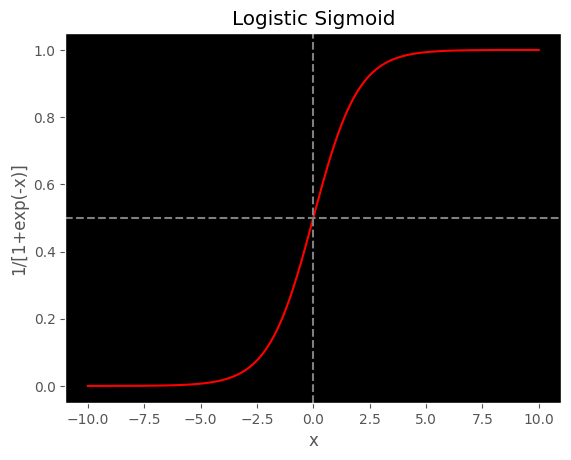

In [18]:
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 1000)
y = 1/(1 + np.exp(-x))
plt.plot(x, y, color='red')
plt.title('Logistic Sigmoid')
plt.xlabel('x')
plt.ylabel('1/[1+exp(-x)]')
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=0.5, color='gray', linestyle='--')
plt.gca().set_facecolor('black')
plt.gca().grid(visible=False)
plt.show()

#### Softplus Function
$\zeta = log(1+exp(x))$

Useful for generating $\beta$ or $\alpha$ parameter of a Normal distribution, since it $\in (0,\infty)$

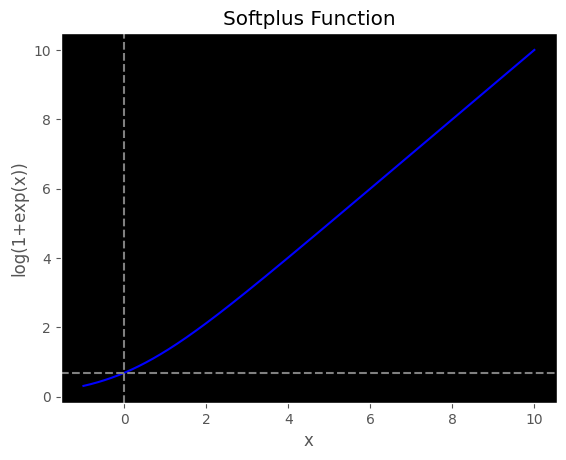

In [20]:
x = np.linspace(-1, 10, 1000)
y = np.log(1+np.exp(x))
plt.plot(x, y, color='blue')
plt.title('Softplus Function')
plt.xlabel('x')
plt.ylabel('log(1+exp(x))')
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=np.log(2), color='gray', linestyle='--')
plt.gca().set_facecolor('black')
plt.gca().grid(visible=False)
plt.show()

#### Important Identities

$$\sigma(x) = \frac{\exp(x)}{\exp(x) + \exp(0)}$$

$$\frac{d}{dx}\sigma(x) = \sigma(x)(1 - \sigma(x))$$

$$1 - \sigma(x) = \sigma(-x)$$

$$\log \sigma(x) = -\zeta(-x)$$

$$\frac{d}{dx}\zeta(x) = \sigma(x)$$

$$\forall x \in (0, 1), \quad \sigma^{-1}(x) = \log\left(\frac{x}{1-x}\right)$$

$$\forall x > 0, \quad \zeta^{-1}(x) = \log(\exp(x) - 1)$$

$$\zeta(x) = \int_{-\infty}^{x} \sigma(y)\, dy$$

$$\zeta(x) - \zeta(-x) = x$$

### Bayes Rule
$$P(X|Y)=\frac{P(X)P(Y|X)}{P(Y)}=\frac{P(X)P(Y|X)}{\sum{P(X)P(Y|X)}}$$

### Technical Details of Continuous Variables

**TBD**

### Information Theory

- Likely events have low information content
- Less likely events have higher information content
- Independent events have additive information

**Self-Information** of the event $X=x$: $I(x)=-log(P(x))$ measured in **nats**

**Shannon Entropy** is expected information over entire distribution: $H=-E[log(x)]$. It is called **differential entropy** when $X$ is continuous

**Kullback-Leibler (KL) divergence** measures how different two distributions are $D_{KL}(P||Q)=E[log\frac{P(x)}{Q(x)}]=E[log(P(x))-log(Q(x))]$. 
- It is non-negative and zero only when $P$ and $Q$ are the same distribution in the discrete case or equal *almost everywhere* in the continuous case.
- In case of discrete variables it measures the extra amount of information required to send messages drawn from distribution $P$ using a code that was designed to minimise the length of messages sent from distribution $Q$
- It measures the *distance* between two distributions but is asymmetric i.e $D_{KL}(P||Q) \ne D_{KL}(Q||P)$

**Cross-Entropy** $H(P,Q)=-E_{x\sim P}[log\;Q(x)]$

Written in terms of KL divergence, this is $H(P,Q)=H(P)+D_{KL}(P||Q)$ where $H(P)$ is the Shannon or differential entropy of $P$. 

So minimizing cross-entropy w.r.t. $Q$ is minimizing KL-divergence (since Q is not there in first term)

### Structured Probabilistic Models

Joint probability distributions of a large number of random variables can get very messy.

So we factorize the distribution using conditional probabilities.

e.g. $p(a,b,c)=p(a)p(b|a)p(c|b)$ if $a$ is independent, $b$ depends on $a$ and $c$ depends on $b$

These conditional dependencies can be shown as a Graph, either Directed or Undirected. 

In **Directed Graphs**, the origin of arrow is the parent $P_{a\mathcal{G}}$ of the destination node $a$ and the joint probability of all random variables $X_i$ denoted by $\vec{X}$ is given as
$$p(\vec{X})=\prod_i p(X_i | P_{a\mathcal{G}}(x_i))$$

In **Undirected Graphs**, a collection of comected nodes is called a clique $C^{(i)}$ and each clique is associated with a factor $\phi^{(i)}(C^{(i)})$. These factors are functions and not probabilities. Probability distribution of a configuration of the random variables $\vec{X}$ is then given as
$$p(\vec{X})=\frac{1}{Z}\prod_i \phi^{(i)}(C^{(i)})$$